In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import nltk
import re
import string
import tqdm

from sklearn.model_selection import train_test_split

Загрузим 3 датасета:


*   1 датасет - тексты с твиттера
*   2 датасет - тексты с настроениями на фондовом рынке
*   3 датасет - тексты с отзывами фильмов



In [2]:
! gdown 1P8cyx5qtXzJOSCykRLRpIM3qHQWZdRdM

Downloading...
From: https://drive.google.com/uc?id=1P8cyx5qtXzJOSCykRLRpIM3qHQWZdRdM
To: /content/train_sentiment_twit.csv
100% 4.64M/4.64M [00:00<00:00, 42.1MB/s]


In [3]:
data_rev=pd.read_csv("/content/train_sentiment_twit.csv", encoding='windows-1251')

In [4]:
! gdown 1XCK3B8Szr8mtob_W0pi1t7zHDKf1DiXn

Downloading...
From: https://drive.google.com/uc?id=1XCK3B8Szr8mtob_W0pi1t7zHDKf1DiXn
To: /content/stock_data.csv
100% 480k/480k [00:00<00:00, 12.3MB/s]


In [5]:
data_rev.head()

,textID,text,selected_text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (KmІ),Density (P/KmІ)
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral,morning,0-20,Afghanistan,38928346,652860.0,60
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative,noon,21-30,Albania,2877797,27400.0,105
2,088c60f138,my boss is bullying me...,bullying me,negative,night,31-45,Algeria,43851044,2381740.0,18
3,9642c003ef,what interview! leave me alone,leave me alone,negative,morning,46-60,Andorra,77265,470.0,164
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative,noon,60-70,Angola,32866272,1246700.0,26


In [6]:
data_finan=pd.read_csv('/content/stock_data.csv', encoding='windows-1251')

In [7]:
data_finan.head()

,Text,Sentiment
0,Kickers on my watchlist XIDE TIT SOQ PNK CPW B...,1
1,user: AAP MOVIE. 55% return for the FEA/GEED i...,1
2,user I'd be afraid to short AMZN - they are lo...,1
3,MNTA Over 12.00,1
4,OI Over 21.37,1


In [8]:
! gdown 1Las5XG60pjVYDOMFnWAY6FjGuGe9qMzn

Downloading...
From: https://drive.google.com/uc?id=1Las5XG60pjVYDOMFnWAY6FjGuGe9qMzn
To: /content/movie.csv
100% 52.7M/52.7M [00:01<00:00, 48.6MB/s]


In [9]:
data_movie = pd.read_csv('/content/movie.csv')

In [10]:
data_movie.head()

,text,label
0,I grew up (b. 1965) watching and loving the Th...,0
1,"When I put this movie in my DVD player, and sa...",0
2,Why do people who do not know what a particula...,0
3,Even though I have great interest in Biblical ...,0
4,Im a die hard Dads Army fan and nothing will e...,1


Приведём все датасеты к одному виду, пусть будет только текст и таргет значение, которое мы должны предсказывать

Сначала работаем с датасетом с твитами

In [11]:
data_rev= data_rev[['text','sentiment']]

In [12]:
data_rev.head()

,text,sentiment
0,"I`d have responded, if I were going",neutral
1,Sooo SAD I will miss you here in San Diego!!!,negative
2,my boss is bullying me...,negative
3,what interview! leave me alone,negative
4,"Sons of ****, why couldn`t they put them on t...",negative


In [13]:
data_rev['sentiment'].unique()

array(['neutral', 'negative', 'positive'], dtype=object)

In [14]:
data_rev=data_rev[data_rev['sentiment'].isin(['negative', 'positive'])]

In [15]:
data_rev['sentiment']=data_rev['sentiment'].apply(lambda x: 0 if x=='negative' else 1)

In [16]:
data_rev.head()

,text,sentiment
1,Sooo SAD I will miss you here in San Diego!!!,0
2,my boss is bullying me...,0
3,what interview! leave me alone,0
4,"Sons of ****, why couldn`t they put them on t...",0
6,2am feedings for the baby are fun when he is a...,1


In [17]:
data_rev.shape

(16363, 2)

Теперь работаем с датасетом о фондовом рынке

In [18]:
data_finan['Sentiment'] =data_finan['Sentiment'].apply(lambda x: 0 if x==-1 else 1)

In [19]:
data_finan.head()

,Text,Sentiment
0,Kickers on my watchlist XIDE TIT SOQ PNK CPW B...,1
1,user: AAP MOVIE. 55% return for the FEA/GEED i...,1
2,user I'd be afraid to short AMZN - they are lo...,1
3,MNTA Over 12.00,1
4,OI Over 21.37,1


In [20]:
data_rev.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16363 entries, 1 to 27479
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   text       16363 non-null  object
 1   sentiment  16363 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 383.5+ KB


In [21]:
data_finan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5791 entries, 0 to 5790
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Text       5791 non-null   object
 1   Sentiment  5791 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 90.6+ KB


In [22]:
data_movie.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    40000 non-null  object
 1   label   40000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 625.1+ KB


Посмотрим на содержимое датасетов, чтобы понять имеет ли текст лишние символы, которые нам лучше убрать для нашего обучения

In [ ]:
data_finan.iloc[1568]['Text']

'CEN chomping at the bit here to clear 84 at the 78.6% retrace, earnings next Tuesday 2/5  '

In [ ]:
data_rev.iloc[3159]['text']

'Gossip Fluffodile here. The latest? Mad night with Teg, Jack, Lou, Tess and Frey. Had a gender war. But I was v. sad for a friend also'

In [ ]:
data_movie.iloc[619]['text']

"But to be a little more precise I do not think that it is as bad as it actually could be. Eventhough the actors (famous to semi-famous) didn't do a very great job. Directors fault? Could be the script as well hard for me to say? Anyway, if you are after a lot of cool guns and action this is not the movie for you but they do run around with a lot of ww2 vintage guns. Sort of fun :) Well I guess I could say more but it just doesn't feel as if it's worth it. If you are desperate enough or a Hackman freak see it otherwise don't!<br /><br />Live well and prosper"

Теперь можем соединить все датасеты в 1, чтобы обучалось на полной выборке текстов

In [23]:
data_rev=data_rev.rename(columns={'sentiment':'label'})
data_finan=data_finan.rename(columns = {'Text':'text', 'Sentiment':'label'})


In [24]:
data_rev

,text,label
1,Sooo SAD I will miss you here in San Diego!!!,0
2,my boss is bullying me...,0
3,what interview! leave me alone,0
4,"Sons of ****, why couldn`t they put them on t...",0
6,2am feedings for the baby are fun when he is a...,1
...,...,...
27475,enjoy ur night,1
27476,wish we could come see u on Denver husband l...,0
27477,I`ve wondered about rake to. The client has ...,0
27478,Yay good for both of you. Enjoy the break - y...,1


In [25]:
result = pd.concat([data_movie, data_rev, data_finan], ignore_index=True)

In [26]:
result

,text,label
0,I grew up (b. 1965) watching and loving the Th...,0
1,"When I put this movie in my DVD player, and sa...",0
2,Why do people who do not know what a particula...,0
3,Even though I have great interest in Biblical ...,0
4,Im a die hard Dads Army fan and nothing will e...,1
...,...,...
62149,Industry body CII said #discoms are likely to ...,0
62150,"#Gold prices slip below Rs 46,000 as #investor...",0
62151,Workers at Bajaj Auto have agreed to a 10% wag...,1
62152,"#Sharemarket LIVE: Sensex off dayвЂ™s high, up...",1


<Axes: >

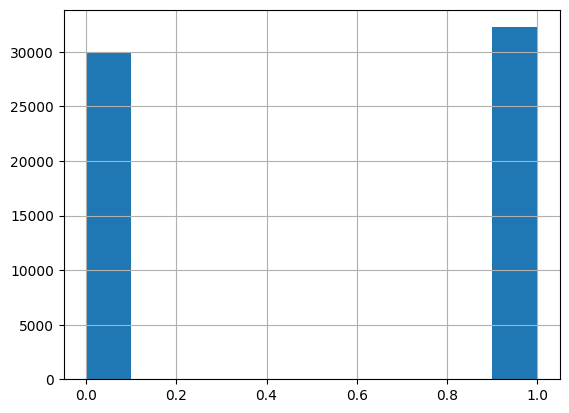

In [27]:
result['label'].hist()

Теперь можем обработать выражения, и символы, которые нам не нравятся. Уберём регулярные выражения и символы и воспользуемся лемматизацией.


---


У нас есть слова, состоящие из 1 буквы (в датасете с твитами были сокращения вплоть до 1 буквы): типа u - you, v-very.
Они не попадают в словарь стоп слов, но их тоже нужно убрать

In [28]:
from string import punctuation
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

nltk.download('wordnet')
nltk.download('punkt_tab')
nltk.download('stopwords')

punctuation_wout_brackets = punctuation.replace('()', "")#чтобы не заменять скобки, потому что в твитах
#они обозначают эмоции
stop_words = stopwords.words('english')
abbreviations =['v', 'u', 'ur', 'r', 'b', 'n', 'y', 'c']
stop_words.append(abbreviations)
def clean_text(text: str):
    pattern = r"<[^>]+>"
    text = re.sub(pattern, "", text)

    text = re.sub('['+re.escape(punctuation_wout_brackets)+']', ' ', text)
    words = word_tokenize(text)

    words = [word.lower() for word in words]

    lemmatizer = nltk.stem.WordNetLemmatizer()
    words = [lemmatizer.lemmatize(word) for word in words]

    stop_words = stopwords.words('english')
    words = [word for word in words if word not in stop_words]

    prepared_text = " ".join(words)

    return prepared_text

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [29]:
data_clean= result.copy()
data_clean['text'] = result['text'].apply(lambda x: clean_text(x))
data_clean.head()

,text,label
0,grew ( b 1965 ) watching loving thunderbird ma...,0
1,put movie dvd player sat coke chip expectation...,0
2,people know particular time past wa like feel ...,0
3,even though great interest biblical movie wa b...,0
4,im die hard dad army fan nothing ever change g...,1


In [ ]:
data_clean.iloc[5678]['text']

'one favorite actor james spader expected film least tolerable first half hour watched rest remote control hand fast forward wa ready trite standard one know going happen scene one even predict dialogue word word one movie make one scratch one head say movie ever get made effort say something positive add mildly entertaining special effect whole seen 5 sci fi movie 9 year old favor skip one'

Разделим данные на train и test

In [30]:
X = data_clean['text']
y = data_clean['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Попробуем сделать векторы с помощью разных векторизаторов.


---


Начнём с CountVectorizer

In [31]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(ngram_range=(1, 1), tokenizer=word_tokenize)

X_train_vectorized_bow = vectorizer.fit_transform(X_train)
X_test_vectorized_bow = vectorizer.transform(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

clf = LogisticRegression(random_state=42)
clf.fit(X_train_vectorized_bow, y_train)

pred = clf.predict(X_test_vectorized_bow)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.85      0.84      0.84      5996
           1       0.85      0.86      0.86      6435

    accuracy                           0.85     12431
   macro avg       0.85      0.85      0.85     12431
weighted avg       0.85      0.85      0.85     12431



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Попробуем другой способ TF-IFD

In [33]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [34]:
vectorizer = TfidfVectorizer(ngram_range=(1,1), tokenizer= word_tokenize)

X_train_vectorized_tfidf = vectorizer.fit_transform(X_train)
X_test_vectorized_tfidf = vectorizer.transform(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [35]:
clf = LogisticRegression(random_state=42)
clf.fit(X_train_vectorized_tfidf, y_train)

pred_tfidf = clf.predict(X_test_vectorized_tfidf)
print(classification_report(y_test, pred_tfidf))

              precision    recall  f1-score   support

           0       0.87      0.83      0.85      5996
           1       0.85      0.88      0.87      6435

    accuracy                           0.86     12431
   macro avg       0.86      0.86      0.86     12431
weighted avg       0.86      0.86      0.86     12431



In [36]:
import joblib
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')
joblib.dump(clf, 'sentiment_classifier.pkl')

['sentiment_classifier.pkl']

Теперь идём дальше и пробуем word2vec

In [ ]:
#!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 41.9 MB/s eta 0:00:00


In [ ]:
from gensim.models import Word2Vec

In [ ]:
X_train_tokenized = [word_tokenize(text) for text in X_train]
X_test_tokenized = [word_tokenize(text) for text in X_test]

word2vec = Word2Vec(sentences = X_train_tokenized, vector_size=300, window=5, seed=42, workers=1)

In [ ]:
from tqdm import tqdm
def process_sentense_with_embedding(sentences, max_length, embedding_model, embedding_dim, mean=True):

  all_embeddings=[]

  for sentence in tqdm(sentences):
    embeddings=[]

    for token in sentence[:max_length]:
      if token in embedding_model.wv:
        embedding = embedding_model.wv[token]
        embeddings.append(embedding)

    if len(embeddings)==0:
        embeddings = np.zeros((max_length, embedding_dim))

    if mean:
      all_embeddings.append(np.mean(np.array(embeddings), axis=0))
    else:
      count_of_adding = max(0, max_length - len(sentence))
      embeddings.extend([np.zeros(embedding_dim)] * count_of_adding)
      all_embeddings.append(embeddings[:max_length])
  return np.stack(all_embeddings)

In [ ]:
max_length = np.max([len(tokens) for tokens in X_train_tokenized])

X_train_processed = process_sentense_with_embedding(X_train_tokenized, max_length, word2vec, 300)
X_test_processed = process_sentense_with_embedding(X_test_tokenized, max_length, word2vec, 300)

100%|██████████| 12431/12431 [00:02<00:00, 6078.90it/s]


In [ ]:
clf= LogisticRegression(random_state=42)
clf.fit(X_train_processed, y_train)

pred_word2vec = clf.predict(X_test_processed)
print(classification_report(y_test, pred_word2vec))

              precision    recall  f1-score   support

           0       0.80      0.78      0.79      5996
           1       0.80      0.82      0.81      6435

    accuracy                           0.80     12431
   macro avg       0.80      0.80      0.80     12431
weighted avg       0.80      0.80      0.80     12431



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Теперь пробуем FastText

In [ ]:
from gensim.models import FastText

In [ ]:
fasttext_model = FastText(sentences = X_train_tokenized, vector_size = 300, window=5, seed=42, workers=1)

In [ ]:
max_length = np.max([len(tokens) for tokens in X_train_tokenized])
X_train_processed_fast_test = process_sentense_with_embedding(X_train_tokenized, max_length, fasttext_model, 300)
X_test_processed_fast_test = process_sentense_with_embedding(X_test_tokenized, max_length, fasttext_model, 300)

100%|██████████| 12431/12431 [00:07<00:00, 1613.09it/s]


In [ ]:
clf = LogisticRegression(random_state=42)
clf.fit(X_train_processed_fast_test, y_train)

pred_fast_text = clf.predict(X_test_processed_fast_test)
print(classification_report(y_test, pred_fast_text))

              precision    recall  f1-score   support

           0       0.79      0.76      0.78      5996
           1       0.79      0.81      0.80      6435

    accuracy                           0.79     12431
   macro avg       0.79      0.79      0.79     12431
weighted avg       0.79      0.79      0.79     12431



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Теперь пробуем GloVe

In [ ]:
from gensim.models import KeyedVectors
from gensim.downloader import load
glove_model = load('glove-wiki-gigaword-300')

[==================================================] 100.0% 376.1/376.1MB downloaded


In [ ]:
def process_sentences_with_embeddings(senteces, max_length, embedding_model,
                                      embedding_dim, mean=True):
    all_embeddings = []

    for tokens in tqdm(senteces):

        embeddings = []
        for token in tokens[:max_length]:
            if token in embedding_model:
                embedding = embedding_model[token]
                embeddings.append(embedding)

        if len(embeddings) == 0:
            embeddings = np.zeros((max_length, embedding_dim))

        if mean:
            all_embeddings.append(np.mean(np.array(embeddings), axis=0))
        else:
            count_of_adding = max(0, max_length - len(tokens))
            embeddings.extend([np.zeros(embedding_dim)] * count_of_adding)
            all_embeddings.append(embeddings[:max_length])

    return np.stack(all_embeddings)

In [ ]:
max_length =np.max([len(tokens) for tokens in X_train_tokenized])

X_train_processed_glove = process_sentences_with_embeddings(X_train_tokenized, max_length, glove_model, 300)
X_test_processed_glove = process_sentences_with_embeddings(X_test_tokenized, max_length, glove_model, 300)


100%|██████████| 12431/12431 [00:04<00:00, 3040.22it/s]


In [ ]:
clf = LogisticRegression(random_state=42)
clf.fit(X_train_processed_glove, y_train)

pred_glove = clf.predict(X_test_processed_glove)
print(classification_report(y_test, pred_glove))

              precision    recall  f1-score   support

           0       0.79      0.79      0.79      5996
           1       0.80      0.81      0.81      6435

    accuracy                           0.80     12431
   macro avg       0.80      0.80      0.80     12431
weighted avg       0.80      0.80      0.80     12431



Теперь попробуем Bert

In [ ]:
from transformers import BertTokenizer, BertModel
import torch

In [ ]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
import random
random_seed=42
if torch.cuda.is_available():
  torch.cuda.manual_seed_all(random_seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

In [ ]:
device

device(type='cuda')

In [ ]:
def get_bert_embeddings(text):
  inputs = tokenizer(text, return_tensors = 'pt', padding=True, truncation=True, max_length=128).to(device)

  with torch.no_grad():
    outputs = model(**inputs)

  embeddings = outputs.last_hidden_state[:, 0, :].squeeze().cpu().numpy()
  return embeddings

In [ ]:
X_train_bert=[]
for text in tqdm(X_train):
  embedding = get_bert_embeddings(text)
  X_train_bert.append(embedding)

X_test_bert=[]
for text in tqdm(X_test):
  embedding = get_bert_embeddings(text)
  X_test_bert.append(embedding)


100%|██████████| 12431/12431 [02:08<00:00, 96.53it/s] 


In [ ]:
clf = LogisticRegression(random_state=42)
clf.fit(X_train_bert, y_train)

pred_bert = clf.predict(X_test_bert)
print(classification_report(y_test, pred_bert))


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


              precision    recall  f1-score   support

           0       0.78      0.77      0.77      5996
           1       0.78      0.79      0.79      6435

    accuracy                           0.78     12431
   macro avg       0.78      0.78      0.78     12431
weighted avg       0.78      0.78      0.78     12431



Сделаем итоговую таблицу со всеми итогами

In [ ]:
def get_metrics_dict(y_true, y_pred, model_name):
    report = classification_report(y_true, y_pred, output_dict=True)
    return {
        'Model': model_name,
        'Precision (macro)': report['macro avg']['precision'],
        'Recall (macro)': report['macro avg']['recall'],
        'F1-Score (macro)': report['macro avg']['f1-score'],
        'Precision (weighted)': report['weighted avg']['precision'],
        'Recall (weighted)': report['weighted avg']['recall'],
        'F1-Score (weighted)': report['weighted avg']['f1-score'],
        'Accuracy': report['accuracy']
    }
results = []
results.append(get_metrics_dict(y_test, pred_bert, 'BERT'))
results.append(get_metrics_dict(y_test, pred_word2vec, 'Word2Vec'))
results.append(get_metrics_dict(y_test, pred_glove, 'GloVe'))
results.append(get_metrics_dict(y_test, pred_tfidf, 'TF-IDF'))
results.append(get_metrics_dict(y_test, pred_fast_text, 'FastText'))
results.append(get_metrics_dict(y_test, pred, 'CountVectorizer'))

comparison_table = pd.DataFrame(results)
comparison_table = comparison_table.set_index('Model')
comparison_table = comparison_table.sort_values('F1-Score (weighted)', ascending=False)
comparison_table

,Precision (macro),Recall (macro),F1-Score (macro),Precision (weighted),Recall (weighted),F1-Score (weighted),Accuracy
Model,,,,,,,
TF-IDF,0.858625,0.857059,0.857503,0.858300,0.857936,0.857780,0.857936
CountVectorizer,0.849157,0.848720,0.848893,0.849164,0.849167,0.849120,0.849167
Word2Vec,0.802001,0.801239,0.801483,0.801970,0.801947,0.801822,0.801947
GloVe,0.797962,0.797769,0.797852,0.798127,0.798166,0.798133,0.798166
FastText,0.787326,0.786405,0.786671,0.787273,0.787225,0.787055,0.787225
BERT,0.780173,0.779914,0.780019,0.780336,0.780388,0.780337,0.780388


Итого видим, что наилучший результат из исследуемых способов показал TF-IDF

Исследуем теперь каждый датасет по отдельности. Возможно для разных датасетов разные метрики дают лучший результат.

Очистим датасеты

In [ ]:
data_rev_clean = data_rev.copy()
data_rev_clean['text'] = data_rev['text'].apply(lambda x: clean_text(x))

data_finan_clean = data_finan.copy()
data_finan_clean['text'] = data_finan['text'].apply(lambda x: clean_text(x))

data_movie_clean = data_movie.copy()
data_movie_clean['text']= data_movie['text'].apply(lambda x: clean_text(x))

In [ ]:
data_rev

,text,label
1,Sooo SAD I will miss you here in San Diego!!!,0
2,my boss is bullying me...,0
3,what interview! leave me alone,0
4,"Sons of ****, why couldn`t they put them on t...",0
6,2am feedings for the baby are fun when he is a...,1
...,...,...
27475,enjoy ur night,1
27476,wish we could come see u on Denver husband l...,0
27477,I`ve wondered about rake to. The client has ...,0
27478,Yay good for both of you. Enjoy the break - y...,1


Разделим данные на train и test

In [ ]:
from sklearn.model_selection import train_test_split
X_rev = data_rev_clean['text']
y_rev = data_rev_clean['label']

X_train_rev, X_test_rev, y_train_rev, y_test_rev = train_test_split(X_rev, y_rev, test_size=0.2, random_state=42)

X_finan = data_finan_clean['text']
y_finan = data_finan_clean['label']

X_train_finan, X_test_finan, y_train_finan, y_test_finan = train_test_split(X_finan, y_finan, test_size=0.2, random_state=42)

X_movie = data_movie_clean['text']
y_movie = data_movie_clean['label']

X_train_movie, X_test_movie, y_train_movie, y_test_movie = train_test_split(X_movie, y_movie, test_size=0.2, random_state=42)

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(ngram_range=(1, 1), tokenizer=word_tokenize)

X_train_rev_vectorized_bow = vectorizer.fit_transform(X_train_rev)
X_test_rev_vectorized_bow = vectorizer.transform(X_test_rev)

vectorizer = CountVectorizer(ngram_range=(1, 1), tokenizer=word_tokenize)

X_train_finan_vectorized_bow = vectorizer.fit_transform(X_train_finan)
X_test_finan_vectorized_bow = vectorizer.transform(X_test_finan)

vectorizer = CountVectorizer(ngram_range=(1, 1), tokenizer=word_tokenize)

X_train_movie_vectorized_bow = vectorizer.fit_transform(X_train_movie)
X_test_movie_vectorized_bow = vectorizer.transform(X_test_movie)

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [ ]:
def get_metrics_dict_data(y_true, y_pred, model_name, name_dataset):
    report = classification_report(y_true, y_pred, output_dict=True)
    return {
        'Model': model_name,
        'Data_name': name_dataset,
        'Precision (macro)': report['macro avg']['precision'],
        'Recall (macro)': report['macro avg']['recall'],
        'F1-Score (macro)': report['macro avg']['f1-score'],
        'Precision (weighted)': report['weighted avg']['precision'],
        'Recall (weighted)': report['weighted avg']['recall'],
        'F1-Score (weighted)': report['weighted avg']['f1-score'],
        'Accuracy': report['accuracy']
    }

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

clf = LogisticRegression(random_state=42)
clf.fit(X_train_rev_vectorized_bow, y_train_rev)

pred_rev = clf.predict(X_test_rev_vectorized_bow)
result_table=[]
result_table.append(get_metrics_dict_data(y_test_rev, pred_rev, 'CountVectorizer', 'Twits'))

clf = LogisticRegression(random_state=42)
clf.fit(X_train_finan_vectorized_bow, y_train_finan)

pred_finan = clf.predict(X_test_finan_vectorized_bow)
result_table.append(get_metrics_dict_data(y_test_finan, pred_finan, 'CountVectorizer', 'Finance'))

clf = LogisticRegression(random_state=42)
clf.fit(X_train_movie_vectorized_bow, y_train_movie)

pred_movie = clf.predict(X_test_movie_vectorized_bow)
result_table.append(get_metrics_dict_data(y_test_movie, pred_movie, 'CountVectorizer', 'Movies'))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Теперь пробуем использовать TF-TDF для каждого текста


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
vectorizer_rev = TfidfVectorizer(ngram_range=(1,1), tokenizer= word_tokenize)

X_train_rev_vectorized_tfidf = vectorizer_rev.fit_transform(X_train_rev)
X_test_rev_vectorized_tfidf = vectorizer_rev.transform(X_test_rev)

vectorizer_finan = TfidfVectorizer(ngram_range=(1,1), tokenizer= word_tokenize)

X_train_finan_vectorized_tfidf = vectorizer_finan.fit_transform(X_train_finan)
X_test_finan_vectorized_tfidf = vectorizer_finan.transform(X_test_finan)

vectorizer_movie = TfidfVectorizer(ngram_range=(1,1), tokenizer= word_tokenize)

X_train_movie_vectorized_tfidf = vectorizer_movie.fit_transform(X_train_movie)
X_test_movie_vectorized_tfidf = vectorizer_movie.transform(X_test_movie)


/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [ ]:
clf_rev = LogisticRegression(random_state=42)
clf_rev.fit(X_train_rev_vectorized_tfidf, y_train_rev)

pred_rev_tfidf = clf_rev.predict(X_test_rev_vectorized_tfidf)
result_table.append(get_metrics_dict_data(y_test_rev, pred_rev_tfidf, 'TF-IDF', 'Twits'))

clf_finan = LogisticRegression(random_state=42)
clf_finan.fit(X_train_finan_vectorized_tfidf, y_train_finan)

pred_finan_tfidf = clf_finan.predict(X_test_finan_vectorized_tfidf)
result_table.append(get_metrics_dict_data(y_test_finan, pred_finan_tfidf, 'TF-IDF', 'Finance'))

clf_movie = LogisticRegression(random_state=42)
clf_movie.fit(X_train_movie_vectorized_tfidf, y_train_movie)

pred_movie_tfidf = clf_movie.predict(X_test_movie_vectorized_tfidf)
result_table.append(get_metrics_dict_data(y_test_movie, pred_movie_tfidf, 'TF-IDF', 'Movies'))

Теперь попробуем Word2Vec для каждого текста по отдельности

In [ ]:
from gensim.models import Word2Vec

In [ ]:
X_train_rev_tokenized = [word_tokenize(text) for text in X_train_rev]
X_test_rev_tokenized = [word_tokenize(text) for text in X_test_rev]

word2vec_rev = Word2Vec(sentences = X_train_rev_tokenized, vector_size=300, window=5, seed=42, workers=1)

X_train_finan_tokenized = [word_tokenize(text) for text in X_train_finan]
X_test_finan_tokenized = [word_tokenize(text) for text in X_test_finan]

word2vec_finan = Word2Vec(sentences = X_train_finan_tokenized, vector_size=300, window=5, seed=42, workers=1)

X_train_movie_tokenized = [word_tokenize(text) for text in X_train_movie]
X_test_movie_tokenized = [word_tokenize(text) for text in X_test_movie]

word2vec_movie = Word2Vec(sentences = X_train_movie_tokenized, vector_size=300, window=5, seed=42, workers=1)

In [ ]:
max_length_rev = np.max([len(tokens) for tokens in X_train_rev_tokenized])

X_train_rev_processed = process_sentense_with_embedding(X_train_rev_tokenized, max_length_rev, word2vec_rev, 300)
X_test_rev_processed = process_sentense_with_embedding(X_test_rev_tokenized, max_length_rev, word2vec_rev, 300)

max_length_finan = np.max([len(tokens) for tokens in X_train_finan_tokenized])

X_train_finan_processed = process_sentense_with_embedding(X_train_finan_tokenized, max_length_finan, word2vec_finan, 300)
X_test_finan_processed = process_sentense_with_embedding(X_test_finan_tokenized, max_length_finan, word2vec_finan, 300)

max_length_movie = np.max([len(tokens) for tokens in X_train_movie_tokenized])

X_train_movie_processed = process_sentense_with_embedding(X_train_movie_tokenized, max_length_movie, word2vec_movie, 300)
X_test_movie_processed = process_sentense_with_embedding(X_test_movie_tokenized, max_length_movie, word2vec_movie, 300)

100%|██████████| 8000/8000 [00:01<00:00, 4210.60it/s]


In [ ]:
clf = LogisticRegression(random_state=42)
clf.fit(X_train_rev_processed, y_train_rev)

pred_rev_word2vec = clf.predict(X_test_rev_processed)
result_table.append(get_metrics_dict_data(y_test_rev, pred_rev_word2vec, 'Word2Vec', 'Twits'))

clf = LogisticRegression(random_state=42)
clf.fit(X_train_finan_processed, y_train_finan)

pred_finan_word2vec= clf.predict(X_test_finan_processed)
result_table.append(get_metrics_dict_data(y_test_finan, pred_finan_word2vec, 'Word2Vec', 'Finance'))

clf = LogisticRegression(random_state=42)
clf.fit(X_train_movie_processed, y_train_movie)

pred_movie_word2vec = clf.predict(X_test_movie_processed)
result_table.append(get_metrics_dict_data(y_test_movie, pred_movie_word2vec, 'Word2Vec', 'Movies'))

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Теперь пробуем Fast Text для каждого текста по отдельности

In [ ]:
from gensim.models import FastText

In [ ]:
fasttext_model_rev = FastText(sentences = X_train_rev_tokenized, vector_size = 300, window=5, seed=42, workers=1)
fasttext_model_finan = FastText(sentences = X_train_finan_tokenized, vector_size = 300, window=5, seed=42, workers=1)
fasttext_model_movie = FastText(sentences = X_train_movie_tokenized, vector_size = 300, window=5, seed=42, workers=1)

In [ ]:
max_length_rev = np.max([len(tokens) for tokens in X_train_rev_tokenized])
max_length_finan = np.max([len(tokens) for tokens in X_train_finan_tokenized])
max_length_movie = np.max([len(tokens) for tokens in X_train_movie_tokenized])

X_train_rev_processed_fast_test = process_sentense_with_embedding(X_train_rev_tokenized, max_length_rev, fasttext_model_rev, 300)
X_test_rev_processed_fast_test = process_sentense_with_embedding(X_test_rev_tokenized, max_length_rev, fasttext_model_rev, 300)

X_train_finan_processed_fast_test = process_sentense_with_embedding(X_train_finan_tokenized, max_length_finan, fasttext_model_finan, 300)
X_test_finan_processed_fast_test = process_sentense_with_embedding(X_test_finan_tokenized, max_length_finan, fasttext_model_finan, 300)

X_train_movie_processed_fast_test = process_sentense_with_embedding(X_train_movie_tokenized, max_length_movie, fasttext_model_movie, 300)
X_test_movie_processed_fast_test = process_sentense_with_embedding(X_test_movie_tokenized, max_length_movie, fasttext_model_movie, 300)

100%|██████████| 8000/8000 [00:03<00:00, 2633.01it/s]


In [ ]:
clf = LogisticRegression(random_state=42)
clf.fit(X_train_rev_processed_fast_test, y_train_rev)

pred_rev_fast_text = clf.predict(X_test_rev_processed_fast_test)
result_table.append(get_metrics_dict_data(y_test_rev, pred_rev_fast_text, 'FastText', 'Twits'))

clf = LogisticRegression(random_state=42)
clf.fit(X_train_finan_processed_fast_test, y_train_finan)

pred_finan_fast_text = clf.predict(X_test_finan_processed_fast_test)
result_table.append(get_metrics_dict_data(y_test_finan, pred_finan_fast_text, 'FastText', 'Finance'))

clf = LogisticRegression(random_state=42)
clf.fit(X_train_movie_processed_fast_test, y_train_movie)

pred_movie_fast_text = clf.predict(X_test_movie_processed_fast_test)
result_table.append(get_metrics_dict_data(y_test_movie, pred_movie_fast_text, 'FastText', 'Movies'))

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/l

Теперь пробуем GloVe для каждого текста по отдельности

In [ ]:
max_length_rev =np.max([len(tokens) for tokens in X_train_rev_tokenized])
max_length_finan =np.max([len(tokens) for tokens in X_train_finan_tokenized])
max_length_movie=np.max([len(tokens) for tokens in X_train_movie_tokenized])


X_train_rev_processed_glove = process_sentences_with_embeddings(X_train_rev_tokenized, max_length_rev, glove_model, 300)
X_test_rev_processed_glove = process_sentences_with_embeddings(X_test_rev_tokenized, max_length_rev, glove_model, 300)


X_train_finan_processed_glove = process_sentences_with_embeddings(X_train_finan_tokenized, max_length_finan, glove_model, 300)
X_test_finan_processed_glove = process_sentences_with_embeddings(X_test_finan_tokenized, max_length_finan, glove_model, 300)


X_train_movie_processed_glove = process_sentences_with_embeddings(X_train_movie_tokenized, max_length_movie, glove_model, 300)
X_test_movie_processed_glove = process_sentences_with_embeddings(X_test_movie_tokenized, max_length_movie, glove_model, 300)

100%|██████████| 8000/8000 [00:02<00:00, 3779.13it/s]


In [ ]:
clf = LogisticRegression(random_state=42)
clf.fit(X_train_rev_processed_glove, y_train_rev)

pred_rev_glove = clf.predict(X_test_rev_processed_glove)
result_table.append(get_metrics_dict_data(y_test_rev, pred_rev_glove, 'GloVe', 'Twits'))

clf = LogisticRegression(random_state=42)
clf.fit(X_train_finan_processed_glove, y_train_finan)

pred_finan_glove = clf.predict(X_test_finan_processed_glove)
result_table.append(get_metrics_dict_data(y_test_finan, pred_finan_glove, 'GloVe', 'Finance'))

clf = LogisticRegression(random_state=42)
clf.fit(X_train_movie_processed_glove, y_train_movie)

pred_movie_glove = clf.predict(X_test_movie_processed_glove)
result_table.append(get_metrics_dict_data(y_test_movie, pred_movie_glove, 'GloVe', 'Movies'))

Теперь пробуем Bert отдельно для каждого текста

In [ ]:
from transformers import BertTokenizer, BertModel
import torch

In [ ]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
device

device(type='cuda')

In [ ]:
X_train_rev_bert=[]
for text in tqdm(X_train_rev):
  embedding = get_bert_embeddings(text)
  X_train_rev_bert.append(embedding)

X_test_rev_bert=[]
for text in tqdm(X_test_rev):
  embedding = get_bert_embeddings(text)
  X_test_rev_bert.append(embedding)

X_train_finan_bert=[]
for text in tqdm(X_train_finan):
  embedding = get_bert_embeddings(text)
  X_train_finan_bert.append(embedding)

X_test_finan_bert=[]
for text in tqdm(X_test_finan):
  embedding = get_bert_embeddings(text)
  X_test_finan_bert.append(embedding)

X_train_movie_bert=[]
for text in tqdm(X_train_movie):
  embedding = get_bert_embeddings(text)
  X_train_movie_bert.append(embedding)

X_test_movie_bert=[]
for text in tqdm(X_test_movie):
  embedding = get_bert_embeddings(text)
  X_test_movie_bert.append(embedding)

100%|██████████| 8000/8000 [01:35<00:00, 84.16it/s]


In [ ]:
clf = LogisticRegression(random_state=42)
clf.fit(X_train_rev_bert, y_train_rev)

pred_rev_bert = clf.predict(X_test_rev_bert)
result_table.append(get_metrics_dict_data(y_test_rev, pred_rev_bert, 'Bert', 'Twits'))

clf = LogisticRegression(random_state=42)
clf.fit(X_train_finan_bert, y_train_finan)

pred_finan_bert = clf.predict(X_test_finan_bert)
result_table.append(get_metrics_dict_data(y_test_finan, pred_finan_bert, 'Bert', 'Finance'))

clf = LogisticRegression(random_state=42)
clf.fit(X_train_movie_bert, y_train_movie)

pred_movie_bert = clf.predict(X_test_movie_bert)
result_table.append(get_metrics_dict_data(y_test_movie, pred_movie_bert, 'Bert', 'Movies'))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

In [ ]:
print(result_table)

[{'Model': 'CountVectorizer', 'Data_name': 'Twits', 'Precision (macro)': 0.8706949486800233, 'Recall (macro)': 0.8707378754655379, 'F1-Score (macro)': 0.8707143780959099, 'Precision (weighted)': 0.8707723175245783, 'Recall (weighted)': 0.8707607699358387, 'F1-Score (weighted)': 0.8707645112132523, 'Accuracy': 0.8707607699358387}, {'Model': 'CountVectorizer', 'Data_name': 'Finance', 'Precision (macro)': 0.7930881844145801, 'Recall (macro)': 0.7764441842310694, 'F1-Score (macro)': 0.7829117293322029, 'Precision (weighted)': 0.8007625146702667, 'Recall (weighted)': 0.8032786885245902, 'F1-Score (weighted)': 0.8004101027228455, 'Accuracy': 0.8032786885245902}, {'Model': 'CountVectorizer', 'Data_name': 'Movies', 'Precision (macro)': 0.8816142460988106, 'Recall (macro)': 0.8816217596721363, 'F1-Score (macro)': 0.8816176584450995, 'Precision (weighted)': 0.8816268541208947, 'Recall (weighted)': 0.881625, 'F1-Score (weighted)': 0.8816255826630873, 'Accuracy': 0.881625}, {'Model': 'TF-IDF', 'Da

In [ ]:
result_table = pd.DataFrame(result_table)

In [ ]:
result_table.groupby('Model')
result_table

,Model,Data_name,Precision (macro),Recall (macro),F1-Score (macro),Precision (weighted),Recall (weighted),F1-Score (weighted),Accuracy
0,CountVectorizer,Twits,0.870695,0.870738,0.870714,0.870772,0.870761,0.870765,0.870761
1,CountVectorizer,Finance,0.793088,0.776444,0.782912,0.800763,0.803279,0.800410,0.803279
2,CountVectorizer,Movies,0.881614,0.881622,0.881618,0.881627,0.881625,0.881626,0.881625
3,TF-IDF,Twits,0.866107,0.866197,0.866140,0.866218,0.866178,0.866186,0.866178
4,TF-IDF,Finance,0.777842,0.738193,0.748970,0.779600,0.780846,0.772510,0.780846
5,TF-IDF,Movies,0.894638,0.894269,0.894332,0.894568,0.894375,0.894350,0.894375
6,Word2Vec,Twits,0.720649,0.717751,0.715814,0.721385,0.716468,0.715535,0.716468
7,Word2Vec,Finance,0.315789,0.500000,0.387097,0.398892,0.631579,0.488964,0.631579
8,Word2Vec,Movies,0.862710,0.862557,0.862593,0.862678,0.862625,0.862610,0.862625
9,FastText,Twits,0.629640,0.626229,0.622574,0.630284,0.624504,0.622022,0.624504


In [ ]:
pivot_f1 = result_table.pivot(index='Model', columns='Data_name', values='F1-Score (weighted)')
pivot_accuracy = result_table.pivot(index='Model', columns='Data_name', values='Accuracy')
pivot_precision = result_table.pivot(index='Model', columns='Data_name', values='Precision (weighted)')
pivot_recall = result_table.pivot(index='Model', columns='Data_name', values='Recall (weighted)')

In [ ]:
print('F1-score (weighted)')
pivot_f1

F1-score (weighted)


Data_name,Finance,Movies,Twits
Model,,,
Bert,0.698553,0.806377,0.820861
CountVectorizer,0.800410,0.881626,0.870765
FastText,0.488964,0.848615,0.622022
GloVe,0.697277,0.835625,0.827656
TF-IDF,0.772510,0.894350,0.866186
Word2Vec,0.488964,0.862610,0.715535


In [ ]:
print('Accuracy')
pivot_accuracy

Accuracy


Data_name,Finance,Movies,Twits
Model,,,
Bert,0.705781,0.806375,0.820959
CountVectorizer,0.803279,0.881625,0.870761
FastText,0.631579,0.848625,0.624504
GloVe,0.708369,0.835625,0.827681
TF-IDF,0.780846,0.894375,0.866178
Word2Vec,0.631579,0.862625,0.716468


In [ ]:
print('Precision (weighted)')
pivot_precision

Precision (weighted)


Data_name,Finance,Movies,Twits
Model,,,
Bert,0.697888,0.806461,0.821147
CountVectorizer,0.800763,0.881627,0.870772
FastText,0.398892,0.848646,0.630284
GloVe,0.699514,0.835743,0.827682
TF-IDF,0.779600,0.894568,0.866218
Word2Vec,0.398892,0.862678,0.721385


In [ ]:
print('Recall (weighted)')
pivot_recall

Recall (weighted)


Data_name,Finance,Movies,Twits
Model,,,
Bert,0.705781,0.806375,0.820959
CountVectorizer,0.803279,0.881625,0.870761
FastText,0.631579,0.848625,0.624504
GloVe,0.708369,0.835625,0.827681
TF-IDF,0.780846,0.894375,0.866178
Word2Vec,0.631579,0.862625,0.716468


Видим, что TF-IDF даёт лучший результат на каждом датасете в отдельности. Отрисуем те слова, которые дают наиболее весомый вклад в предсказание модели

In [ ]:
def get_top_features_tfidf(vectorizer, model, feature_names, top_n=20):
    coefficients = model.coef_[0]

    feature_importance = pd.DataFrame({
        'word': feature_names,
        'coefficient': coefficients
    })

    top_positive = feature_importance.nlargest(top_n, 'coefficient')

    top_negative = feature_importance.nsmallest(top_n, 'coefficient')

    return top_positive, top_negative

In [ ]:
vectorizer_rev

TfidfVectorizer(tokenizer=<function word_tokenize at 0x7fbc1d822f20>)

In [ ]:
feature_names_rev = vectorizer_rev.get_feature_names_out()
top_pos_twits, top_neg_twits = get_top_features_tfidf(
    vectorizer_rev, clf_rev, feature_names_rev, top_n=20
)

In [ ]:
print(top_pos_twits, top_neg_twits)

            word  coefficient
8049        love     8.477367
12994     thanks     7.097987
5859       great     5.957653
1454     awesome     5.548978
6113       happy     5.433606
5732        good     5.419124
12990      thank     5.362550
9113        nice     5.237982
6467        hope     5.000093
4740     excited     4.407067
1051     amazing     4.258429
1833        best     4.061877
14702        yay     3.957363
5656        glad     3.868538
5406         fun     3.797313
3282        cool     3.780915
3536        cute     3.744113
1846      better     3.516546
14247    welcome     3.497483
6470   hopefully     3.494786                 word  coefficient
11262            sad    -6.544298
8625            miss    -5.732276
12120          sorry    -5.289326
6156            hate    -5.263029
12550           suck    -4.778281
1544             bad    -3.916379
2108           bored    -3.882531
11754           sick    -3.867115
13175          tired    -3.826105
10185           poor    -3.664

In [ ]:
feature_names_finan = vectorizer_finan.get_feature_names_out()
top_pos_finan, top_neg_finan = get_top_features_tfidf(
    vectorizer_finan, clf_finan, feature_names_finan, top_n=20
)

In [ ]:
feature_names_movie = vectorizer_movie.get_feature_names_out()
top_pos_movie, top_neg_movie = get_top_features_tfidf(
    vectorizer_movie, clf_movie, feature_names_movie, top_n=20
)

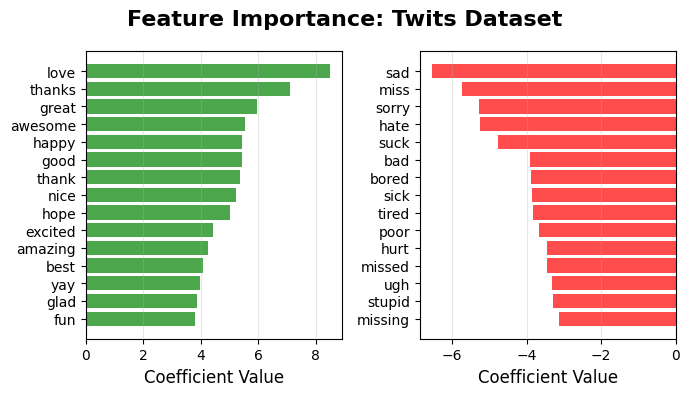

In [ ]:
def plot_top_features(top_positive, top_negative, dataset_name, top_n=15):
    fig, axes = plt.subplots(1, 2, figsize=(7, 4))

    axes[0].barh(top_positive['word'][:top_n], top_positive['coefficient'][:top_n],
                 color='green', alpha=0.7)
    axes[0].set_xlabel('Coefficient Value', fontsize=12)
    axes[0].invert_yaxis()
    axes[0].grid(axis='x', alpha=0.3)

    axes[1].barh(top_negative['word'][:top_n], top_negative['coefficient'][:top_n],
                 color='red', alpha=0.7)
    axes[1].set_xlabel('Coefficient Value', fontsize=12)
    axes[1].invert_yaxis()
    axes[1].grid(axis='x', alpha=0.3)

    plt.suptitle(f'Feature Importance: {dataset_name}', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_top_features(top_pos_twits, top_neg_twits, 'Twits Dataset')

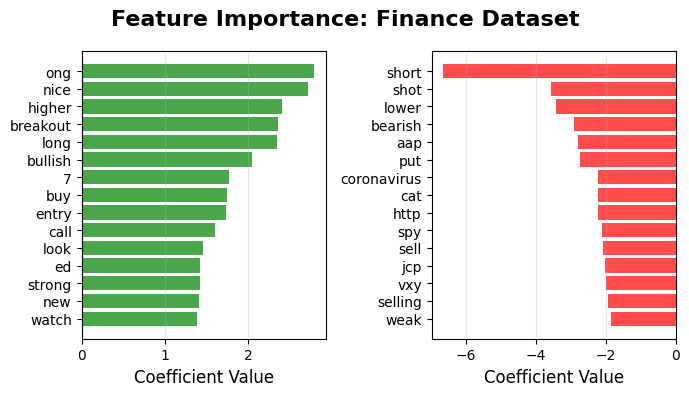

In [ ]:
plot_top_features(top_pos_finan, top_neg_finan, 'Finance Dataset')

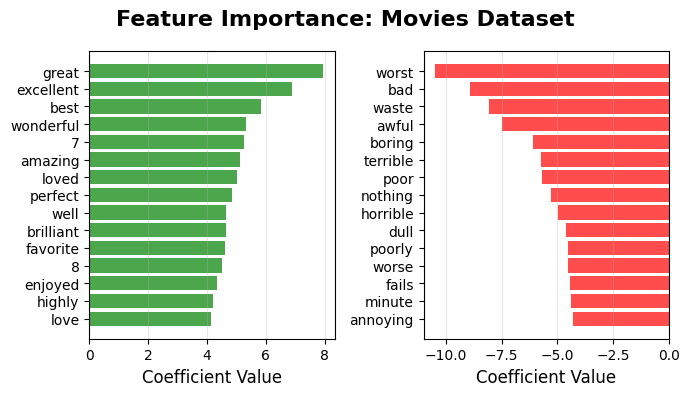

In [ ]:
plot_top_features(top_pos_movie, top_neg_movie, 'Movies Dataset')

Теперь попробуем отойти от этих методов и воспользоваться CatBoost

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 1.9 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostClassifier

In [ ]:
model_cat = CatBoostClassifier(iterations=150, learning_rate=0.1, depth=6, verbose=10, random_seed=42, text_features=[0])
data_train= pd.DataFrame({'text': X_train})
data_test = pd.DataFrame({'text':X_test})

model_cat.fit(data_train, y_train)

0:	learn: 0.6552411	total: 284ms	remaining: 42.4s
10:	learn: 0.4863743	total: 3.98s	remaining: 50.2s
20:	learn: 0.4428600	total: 8.79s	remaining: 54s
30:	learn: 0.4253562	total: 13.2s	remaining: 50.7s
40:	learn: 0.4145099	total: 18.3s	remaining: 48.7s
50:	learn: 0.4071472	total: 21.5s	remaining: 41.7s
60:	learn: 0.4015212	total: 23.9s	remaining: 34.9s
70:	learn: 0.3957938	total: 28.9s	remaining: 32.1s
80:	learn: 0.3912633	total: 31.7s	remaining: 27s
90:	learn: 0.3873421	total: 35.3s	remaining: 22.9s
100:	learn: 0.3826940	total: 37.7s	remaining: 18.3s
110:	learn: 0.3784961	total: 40.2s	remaining: 14.1s
120:	learn: 0.3741724	total: 42.6s	remaining: 10.2s
130:	learn: 0.3701282	total: 45.1s	remaining: 6.55s
140:	learn: 0.3668075	total: 49.1s	remaining: 3.13s
149:	learn: 0.3641290	total: 51.4s	remaining: 0us


CatBoostClassifier(depth=6, iterations=150, learning_rate=0.1, random_seed=42, text_features=[0], verbose=10)

In [ ]:
from sklearn.metrics import classification_report

pred_cat = model_cat.predict(data_test)
print(classification_report(y_test, pred_cat))

              precision    recall  f1-score   support

           0       0.84      0.82      0.83      5996
           1       0.84      0.86      0.85      6435

    accuracy                           0.84     12431
   macro avg       0.84      0.84      0.84     12431
weighted avg       0.84      0.84      0.84     12431

